# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.52) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.45)), and
derive its variance (Eq. (2.47)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.48)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

### Solution

**1a)** In component form, we may write

$$
y_i = \sum_j X_{ij}\theta_j + \varepsilon_i = \boldsymbol{X}_{i,*} \boldsymbol{\theta} + \varepsilon_i.
$$

Since the $\mathbb{E}[\varepsilon_i] = 0$, we see that

$$
\mathbb{E}[y_i] = \mathbb{E}[\boldsymbol{X}_{i,*} \boldsymbol{\theta} + \varepsilon_i] = \mathbb{E}[\boldsymbol{X}_{i,*} \boldsymbol{\theta}] + \mathbb{E}[\varepsilon_i] = \mathbb{E}[\boldsymbol{X}_{i,*} \boldsymbol{\theta}].
$$

Since $\boldsymbol{X}$ and $\boldsymbol{\theta}$ are independent from one another, $\mathbb{E}[\boldsymbol{X}_{i,*} \boldsymbol{\theta}] = \mathbb{E}[\boldsymbol{X}_{i,*}] \mathbb{E}[\boldsymbol{\theta}]$. Since both $\boldsymbol{X}$ and $\boldsymbol{\theta}$ are nonstochastic, we end up with

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*} \boldsymbol{\theta}.
$$

We now calculate $(y_i - \mathbb{E}[y_i])^2$:

$$
(y_i - \mathbb{E}[y_i])^2 = (\boldsymbol{X}_{i,*} \boldsymbol{\theta} + \varepsilon_i - \boldsymbol{X}_{i,*} \boldsymbol{\theta})^2 = \varepsilon_i^2.
$$

Since (by definition) $\operatorname{Var}(\varepsilon_i) = \sigma^2$, we then have

$$
\operatorname{Var}(y_i) = \mathbb{E}[\varepsilon_i^2] = \mathbb{E}[(\varepsilon_i - \mathbb{E}[\varepsilon_i])^2] = \operatorname{Var}(\varepsilon_i) = \sigma^2.
$$

**1b)** Recall that

$$
\hat{\boldsymbol{\theta}}_{\mathrm{OLS}} = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

Plugging in $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$ yields

$$
\hat{\boldsymbol{\theta}}_{\mathrm{OLS}} = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}) = \boldsymbol{\theta} + \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{\varepsilon}.
$$

Thus,

$$
\mathbb{E}\left[\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\right] = \mathbb{E}[\boldsymbol{\theta}] + \mathbb{E}\left[\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{\varepsilon}\right] = \boldsymbol{\theta} + \mathbb{E}\left[\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\right] \mathbb{E}[\boldsymbol{\varepsilon}] = \boldsymbol{\theta}.
$$

In other words, $\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}$ is unbiased. We now find an expression for the variance:

$$
\operatorname{Var}\left(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\right) = \mathbb{E}\left[\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}^2\right] - \left(\mathbb{E}\left[\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\right]\right)^2 = \mathbb{E}\left[\left(\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}\right)^2\right] - \boldsymbol{\theta}^2.
$$

Notice that

$$
\left(\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}\right)^2 = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}\boldsymbol{y}^T\boldsymbol{X}\left(\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\right)^T = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}\boldsymbol{y}^T\boldsymbol{X}\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

Hence, using $\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$,

$$
\mathbb{E}\left[\left(\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}\right)^2\right] = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T \mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] \boldsymbol{X}\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1} = \boldsymbol{\theta}\boldsymbol{\theta}^T + \sigma^2 \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1} = \boldsymbol{\theta}^2 + \sigma^2 \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

Thus,

$$
\operatorname{Var}\left(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\right) = \boldsymbol{\theta}^2 + \sigma^2 \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1} - \boldsymbol{\theta}^2 = \sigma^2 \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1},
$$
as desired.

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.49)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.52),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

### Solution

**2a)** Substituting for $\boldsymbol{y}$, we get

$$
\mathbb{E}\left[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2\right] = \mathbb{E}\left[(\boldsymbol{f} + \boldsymbol{\varepsilon} - \tilde{\boldsymbol{y}})^2\right] = \mathbb{E}\left[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}] + \boldsymbol{\varepsilon} + \mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2\right],
$$

where $\boldsymbol{f} = f(\boldsymbol{x})$. Expanding this yields

$$
\mathbb{E}\left[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2\right] = \mathbb{E}\left[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2\right] + \mathbb{E}\left[(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2\right] + \mathbb{E}\left[\boldsymbol{\varepsilon}^2\right] + 2 \mathbb{E}[\boldsymbol{\varepsilon}(\boldsymbol{f} - \tilde{\boldsymbol{y}})] - 2\mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])].
$$

Here, the first three terms are

$$
\mathbb{E}\left[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2\right] = \frac{1}{n} \sum_i (f_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2,
$$

$$
\mathbb{E}\left[(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2\right] = \frac{1}{n} \sum_i (\tilde{y}_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2
$$

and

$$
\mathbb{E}\left[\boldsymbol{\varepsilon}^2\right] = \sigma^2.
$$

The first cross term is simple to evaluate, since $\boldsymbol{\varepsilon}$ is independent of $\boldsymbol{f} - \tilde{\boldsymbol{y}}$:

$$
\mathbb{E}[\boldsymbol{\varepsilon}(\boldsymbol{f} - \tilde{\boldsymbol{y}})] = \mathbb{E}[\boldsymbol{\varepsilon}] \mathbb{E}[\boldsymbol{f} - \tilde{\boldsymbol{y}}] = 0.
$$

Then only the last cross term remains:

$$
\mathbb{E}[(\boldsymbol{f} - \mathbb{E}[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - \mathbb{E}[\tilde{\boldsymbol{y}}])] = \mathbb{E}[\boldsymbol{f} \cdot \tilde{\boldsymbol{y}}] - \mathbb{E}[\boldsymbol{f}]\mathbb{E}[\tilde{\boldsymbol{y}}] - \mathbb{E}[\tilde{\boldsymbol{y}}]\mathbb{E}[\tilde{\boldsymbol{y}}] + \left(\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2 = \mathbb{E}[\boldsymbol{f}] \mathbb{E}[\tilde{\boldsymbol{y}}] - \mathbb{E}[\boldsymbol{f}]\mathbb{E}[\tilde{\boldsymbol{y}}] = 0.
$$

Collecting all of the terms then gives

$$
\mathbb{E}\left[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2\right] = \frac{1}{n} \sum_i (f_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \frac{1}{n} \sum_i (\tilde{y}_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 + \sigma^2.
$$

**2b)** The expectation value runs over the randomness of the training set (the $x$-values are randomly chosen and $\tilde{y}$ fitted with these values in mind) and the noise. The first term,

$$
\frac{1}{n} \sum_i (f_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2,
$$

is a measure of how accurate the fit is compared to the true function (the bias). The lower this value is, the more accurate the predicted model is. The second term,

$$
\frac{1}{n} \sum_i (\tilde{y}_i - \mathbb{E}[\tilde{\boldsymbol{y}}])^2,
$$

is a measure of how precise the fit is (the variance of the fit). Lastly, the term $\sigma^2$ is the noise floor, below which it becomes difficult to distinguish small values of $f$ (i.e. $f(x) < \sigma^2$) and  from the noise.

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.52): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

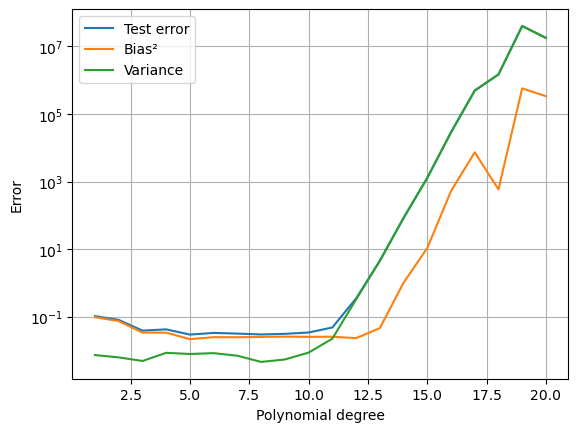

Optimal degree 5


In [2]:
# Your code for exercise 3 here

n_bootstrap = 100
degrees = np.arange(1, 21)

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=2026
)



test_errors = []
bias_squared = []
variances = []


for degree in degrees:

    y_pred_bootstrap = np.zeros(
        (n_bootstrap, len(x_test))
    )

    for i in range(n_bootstrap):

        x_boot, y_boot = resample(
            x_train,
            y_train,
            replace=True,
            random_state=2026 + i
        )

        model = make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )

        model.fit(x_boot, y_boot)

        y_pred_bootstrap[i, :] = model.predict(x_test).ravel()


    y_pred_mean = np.mean(
        y_pred_bootstrap,
        axis=0
    )


    error = np.mean(
        (y_test.ravel() - y_pred_bootstrap) ** 2
    )


    bias = np.mean(
        (y_test.ravel() - y_pred_mean) ** 2
    )


    variance = np.mean(
        (y_pred_bootstrap - y_pred_mean) ** 2
    )


    test_errors.append(error)
    bias_squared.append(bias)
    variances.append(variance)


plt.plot(degrees, test_errors, label="Test error")
plt.plot(degrees, bias_squared, label="Bias²")
plt.plot(degrees, variances, label="Variance")
plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()
print("Optimal degree", degrees[np.argmin(test_errors)])

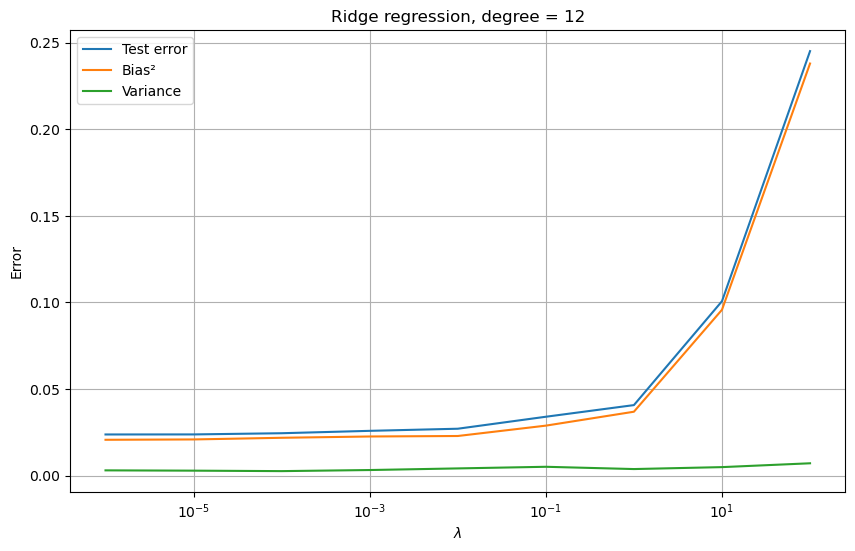

In [3]:
degree = 12
n_bootstrap = 100

lambdas = np.logspace(-6, 2, 9)



x = np.linspace(-3, 3, n).reshape(-1, 1)

y = (
    np.exp(-x**2)
    + 1.5 * np.exp(-(x - 2)**2)
    + np.random.normal(0, 0.1, x.shape)
)



x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=2026
)



def ridge_model(lam):

    return make_pipeline(
        PolynomialFeatures(degree),
        StandardScaler(),
        Ridge(alpha=lam)
    )



test_errors = []
bias_squared = []
variances = []


for lam in lambdas:

    y_pred_bootstrap = np.zeros(
        (n_bootstrap, len(x_test))
    )

    for i in range(n_bootstrap):

        x_boot, y_boot = resample(
            x_train,
            y_train,
            replace=True,
            random_state=2026 + i
        )

        model = ridge_model(lam)

        model.fit(
            x_boot,
            y_boot
        )

        y_pred_bootstrap[i] = (
            model.predict(x_test).ravel()
        )


    y_pred_mean = np.mean(
        y_pred_bootstrap,
        axis=0
    )


    test_error = np.mean(
        (y_test.ravel() - y_pred_bootstrap) ** 2
    )


    bias = np.mean(
        (y_test.ravel() - y_pred_mean) ** 2
    )


    variance = np.mean(
        (y_pred_bootstrap - y_pred_mean) ** 2
    )


    test_errors.append(test_error)
    bias_squared.append(bias)
    variances.append(variance)



plt.figure(figsize=(10, 6))

plt.semilogx(
    lambdas,
    test_errors,
    label="Test error"
)

plt.semilogx(
    lambdas,
    bias_squared,
    label="Bias²"
)

plt.semilogx(
    lambdas,
    variances,
    label="Variance"
)

plt.xlabel(r"$\lambda$")
plt.ylabel("Error")
plt.title("Ridge regression, degree = 12")

plt.legend()
plt.grid()
plt.show()

According to the graph ,we see that an increasing lambda seems to reduce variance, at the cost of increasing bias.

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

In [4]:
"""
# Your code for exercise 4 here
nlambdas = 100
lambdas = np.logspace(-3, 5, nlambdas)
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
#poly = PolynomialFeatures(degree=k+1)
#print(x)
x=x.flatten()
y=y.flatten()
print(y)
#scores_KFold = np.zeros((nlambdas, k))


mse_sklearn = np.zeros(nlambdas)
for i, lmb in enumerate(lambdas):
    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(), Ridge(alpha=lmb))
    #print(pipe)
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error", error_score="raise")
    mse_sklearn[i] = np.mean(-scores)
def c_score(x,y, degrees, lambdas):
        mse_sklearn = np.zeros(nlambdas)
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(), Ridge(alpha=lmb))
        #print(pipe)
        scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error", error_score="raise")
        mse_sklearn[i] = np.mean(-scores)
"""

'\n# Your code for exercise 4 here\nnlambdas = 100\nlambdas = np.logspace(-3, 5, nlambdas)\nk = 5\nkfold = KFold(n_splits=k, shuffle=True, random_state=2026)\n#poly = PolynomialFeatures(degree=k+1)\n#print(x)\nx=x.flatten()\ny=y.flatten()\nprint(y)\n#scores_KFold = np.zeros((nlambdas, k))\n\n\nmse_sklearn = np.zeros(nlambdas)\nfor i, lmb in enumerate(lambdas):\n    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(), Ridge(alpha=lmb))\n    #print(pipe)\n    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error", error_score="raise")\n    mse_sklearn[i] = np.mean(-scores)\ndef c_score(x,y, degrees, lambdas):\n        mse_sklearn = np.zeros(nlambdas)\n    for i, lmb in enumerate(lambdas):\n        pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(), Ridge(alpha=lmb))\n        #print(pipe)\n        scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error", error_score="raise")\n   

In [5]:
##Your code for exercise 4 here

def cv_mse(model, X, y, k=5, random_state=2026):

    kfold = KFold(
        n_splits=k,
        shuffle=True,
        random_state=random_state
    )

    mse_values = []

    for train_idx, test_idx in kfold.split(X):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        model.fit(X_train, y_train.ravel())

        y_pred = model.predict(X_test)

        mse = np.mean((y_test.ravel() - y_pred)**2)

        mse_values.append(mse)

    return np.mean(mse_values), np.std(mse_values)

def polynomial_model(degree, method="OLS", alpha=1.0):

    if method == "OLS":

        return make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )

    elif method == "Ridge":

        return make_pipeline(
            PolynomialFeatures(degree),
            StandardScaler(),
            Ridge(alpha=alpha)
        )

**4b)** OLS, cv, degree 0-13:

In [6]:
degrees = range(14)

cv_means = []
cv_stds = []

for degree in degrees:

    model = polynomial_model(degree, method="OLS")

    mean_mse, std_mse = cv_mse(
        model,
        x,
        y,
        k=5
    )

    cv_means.append(mean_mse)
    cv_stds.append(std_mse)

best_degree = degrees[np.argmin(cv_means)]

print(f"Optimal degree: {best_degree}")

Optimal degree: 8


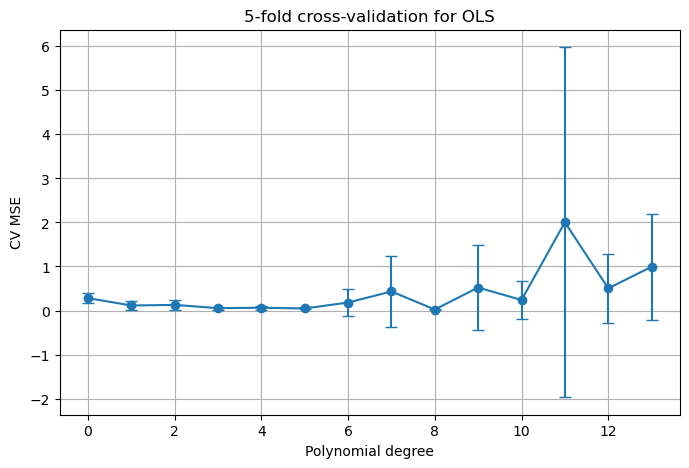

In [7]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    degrees,
    cv_means,
    yerr=cv_stds,
    fmt="o-",
    capsize=4
)

plt.xlabel("Polynomial degree")
plt.ylabel("CV MSE")
plt.title("5-fold cross-validation for OLS")

plt.grid()
plt.show()

We see both bootstrap and CV stays low until around 10 degress where they start going up in MSE, but the optimal degree for Bootstrap was 5 and CV has 8.

**2c**

In [8]:
n_ridge = 100

x_ridge = np.linspace(-3, 3, n_ridge).reshape(-1, 1)

epsilon = np.random.normal(0, 1, (n_ridge, 1))

y_ridge = 3 * x_ridge**2 + epsilon

In [9]:
lambdas = np.logspace(-3, 5, 100)

ridge_cv_means = []
ridge_cv_stds = []

for lam in lambdas:

    model = polynomial_model(
        degree=6,
        method="Ridge",
        alpha=lam
    )

    mean_mse, std_mse = cv_mse(
        model,
        x_ridge,
        y_ridge,
        k=5
    )

    ridge_cv_means.append(mean_mse)
    ridge_cv_stds.append(std_mse)

optimal_lambda = lambdas[np.argmin(ridge_cv_means)]

print(f"Optimal lambda: {optimal_lambda:.4g}")

Optimal lambda: 0.1262


In [10]:
k_values = [5, 10, n_ridge]

optimal_lambdas = {}

for k in k_values:

    mse_values = []

    for lam in lambdas:

        model = polynomial_model(
            degree=6,
            method="Ridge",
            alpha=lam
        )

        mean_mse, _ = cv_mse(
            model,
            x_ridge,
            y_ridge,
            k=k
        )

        mse_values.append(mean_mse)

    best_lambda = lambdas[np.argmin(mse_values)]

    optimal_lambdas[k] = best_lambda

    print(
        f"k = {k}: "
        f"optimal lambda = {best_lambda:.4g}"
    )

k = 5: optimal lambda = 0.1262
k = 10: optimal lambda = 0.1831
k = 100: optimal lambda = 0.3199


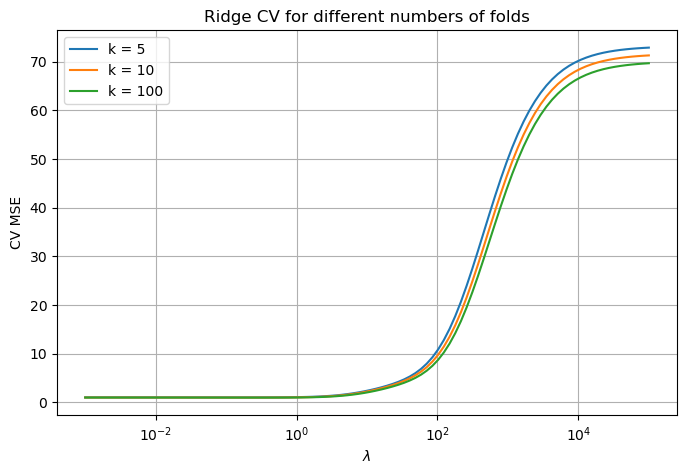

In [11]:
plt.figure(figsize=(8, 5))

for k in k_values:

    mse_values = []

    for lam in lambdas:

        model = polynomial_model(
            degree=6,
            method="Ridge",
            alpha=lam
        )

        mean_mse, _ = cv_mse(
            model,
            x_ridge,
            y_ridge,
            k=k
        )

        mse_values.append(mean_mse)

    plt.semilogx(
        lambdas,
        mse_values,
        label=f"k = {k}"
    )

plt.xlabel(r"$\lambda$")
plt.ylabel("CV MSE")
plt.title("Ridge CV for different numbers of folds")

plt.legend()
plt.grid()
plt.show()

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.48).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.48) fails?)

In [12]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.